# Prospector SED Fitting (Exploratory)

Early/incomplete SED fitting attempts for the AGEL0206 deflector galaxy. This notebook is retained for reference as an alternative approach.

**See `02_Bagpipes_SED_fitting.ipynb` for the primary SED analysis.**

In [ ]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import specutils as spec
# Load the hst image
# fname_full_field = 'AGEL020613-011417A_F140W_WFC3_drz_sci.fits'
# fname = 'AGEL020613-011417A_F140W_WFC3_cutout_L3.fits'

# fname_full_field = 'AGEL020613-011417A_F200LP_WFC3_drc_sci.fits'
# fname = 'AGEL020613-011417A_F200LP_WFC3_cutout_L3.fits'


# hst_image = fits.getdata(fname)
# hdr = fits.getheader(fname_full_field)
# hdr_cutout = fits.getheader(fname)


import astropy.units as u

abmags= np.array([21.7796,  19.1335, 18.9425,  18.6042 ])*u.ABmag
filters = ['f200LP', 'f140W', 'f150W', 'f322W']
wavelengths = np.array([0.2, 1.4, 1.5, 3.22]) * u.micron
fluxes = abmags.to(u.erg / (u.s * u.cm**2 * u.Hz))
plt.figure(figsize=(10,6))
plt.plot(wavelengths, fluxes, 'o-')
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('Wavelength (micron)')
plt.ylabel('Flux (erg/s/cm^2/Hz)')
plt.title('Fluxes from AB magnitudes')
plt.grid(True, alpha=0.3)
plt.show()



(np.float64(0.0029173189541324973), np.float32(0.011757857))

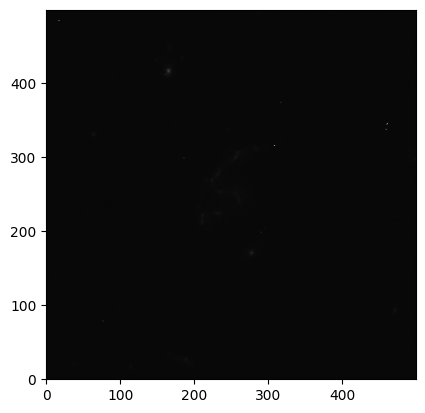

In [69]:
plt.imshow((hst_image), origin='lower', cmap='gray')
np.median(hst_image), np.nanmedian(fits.getdata(fname_full_field))

In [70]:
hdr_cutout

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  500                                                  
NAXIS2  =                  500                                                  
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =             255.1364 / Pixel coordinate of reference point            
CRPIX2  =            1080.9408 / Pixel coordinate of reference point            
PC1_1   =   5.180385286255E-06 / Coordinate transformation matrix element       
PC1_2   =  1.2886614871791E-05 / Coordinate transformation matrix element       
PC2_1   =  1.2886614871791E-05 / Coordinate transformation matrix element       
PC2_2   = -5.1803852862549E-06 / Coordinate transformation matrix element       
CDELT1  =                  1

In [71]:
hdr['PHOTFLAM'], hdr['PHOTZPT']

(5.1851274e-20, -21.1)

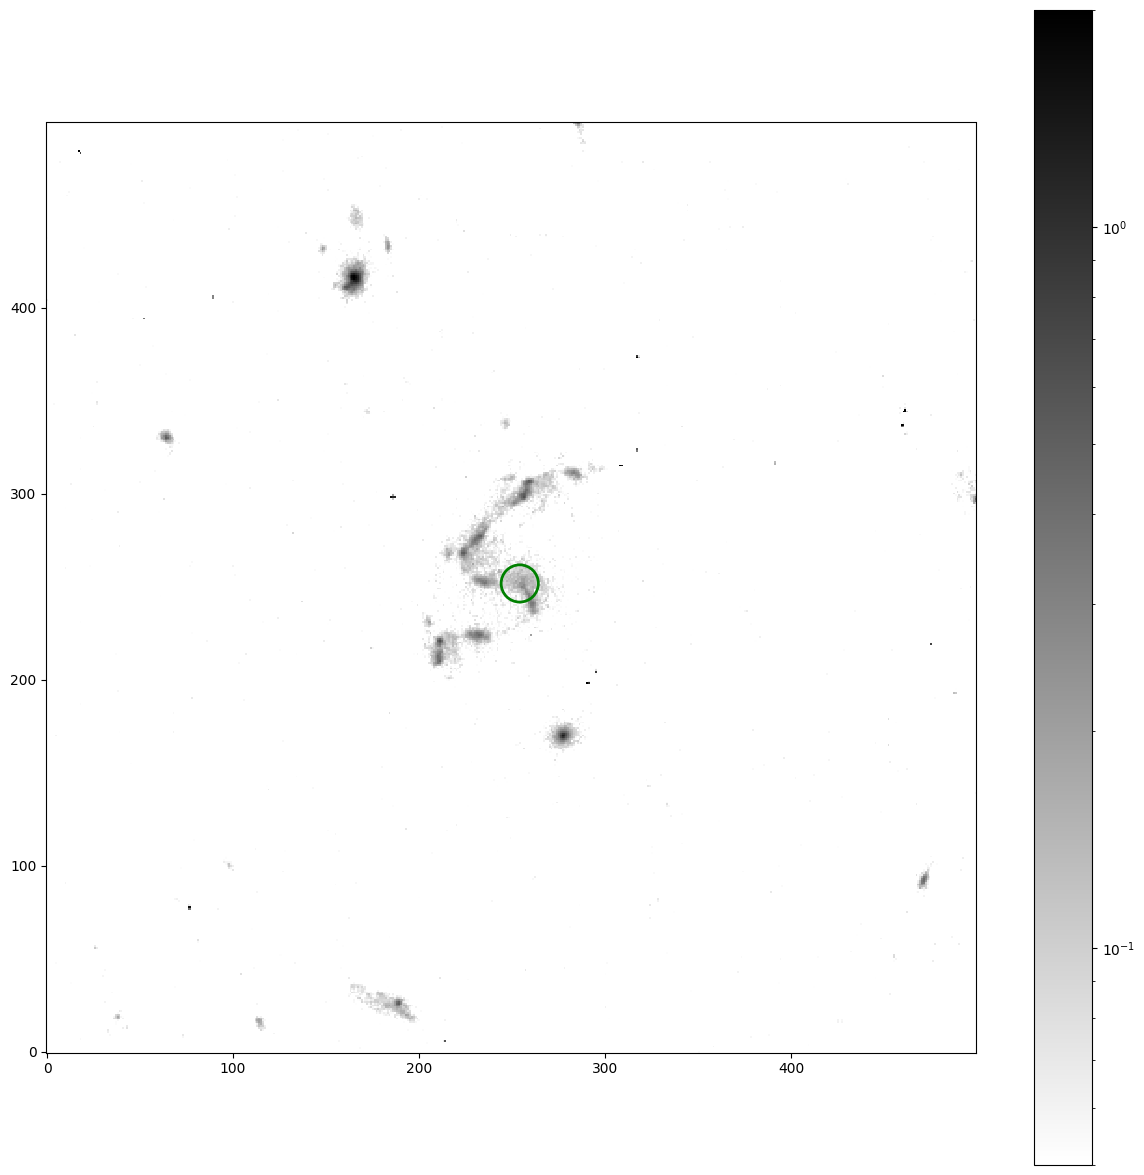

In [72]:
from astropy import units as u
from astropy.coordinates import SkyCoord
from photutils.aperture import SkyCircularAperture
from astropy.wcs import WCS
from photutils.aperture import aperture_photometry
from photutils.aperture import CircularAperture




import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from photutils.aperture import CircularAnnulus, CircularAperture
from photutils.datasets import make_100gaussians_image
from matplotlib.colors import LogNorm


wcs= WCS(hdr_cutout)

positions = SkyCoord(ra = (31.55611000 + 0.00005) * u.deg, dec = (-1.23817000+0.00005) * u.deg,
                     frame='icrs')


aperture = CircularAperture(positions.to_pixel(wcs), r=10.0)
radii = [10., 20., 50., 100., 200., 300.]
#aperture = [CircularAperture(positions.to_pixel(wcs), r=r) for r in radii]


data = np.copy(hst_image)
phot_table = aperture_photometry(data, aperture)
#phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
phot_table



annulus_aperture = CircularAnnulus(positions.to_pixel(wcs), r_in=10, r_out=15)
plt.figure(figsize=(15, 15))
plt.imshow(data, norm=LogNorm(vmin = 5e-2, vmax = 2), 
           interpolation='None', origin='lower', cmap='gray_r',
           )
ap_patches = aperture.plot(color='g', lw=2,
                           label='Photometry aperture')
plt.colorbar()
#ann_patches = annulus_aperture.plot(color='red', lw=2,
#                                    label='Background annulus')
handles = (ap_patches[0], ann_patches[0])


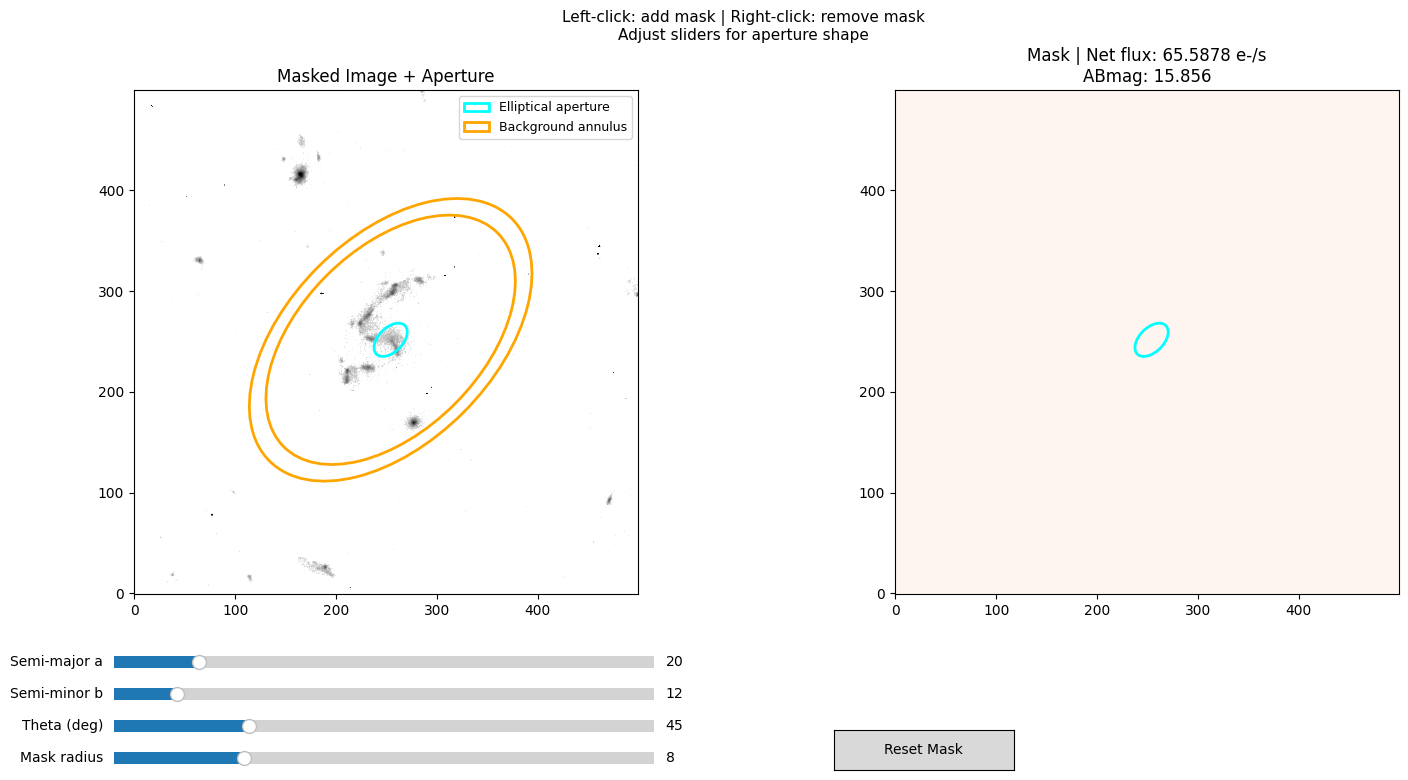

In [76]:
from photutils.aperture import EllipticalAperture, EllipticalAnnulus
from matplotlib.widgets import Button, Slider, RadioButtons
from matplotlib.patches import Ellipse

import matplotlib.patches as mpatches

# --- Parameters (adjust as needed) ---
# Elliptical aperture centered on deflector galaxy
deflector_pos = positions.to_pixel(wcs)  # use existing WCS position

# Initial ellipse parameters
aper_a = 20.0      # semi-major axis (pixels)
aper_b = 12.0      # semi-minor axis (pixels)
aper_theta = np.deg2rad(45)  # orientation angle (radians)

# Background annulus
bkg_r_in = 150.0
bkg_r_out = 170.0

# --- Mask for contaminating source (click to define circular mask regions) ---
masked_data = np.copy(data)
mask = np.zeros(data.shape, dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(bottom=0.25)

def update_plot():
    for ax in axes:
        ax.cla()
    
    display_data = np.copy(masked_data)
    display_data[mask] = np.nan

    axes[0].imshow(display_data, norm=LogNorm(vmin=5e-2, vmax=2),
                   interpolation='None', origin='lower', cmap='gray_r')
    axes[0].set_title('Masked Image + Aperture')

    # Draw elliptical aperture
    aper = EllipticalAperture(deflector_pos, a=aper_a, b=aper_b, theta=aper_theta)
    bkg_aper = EllipticalAnnulus(deflector_pos, a_in=bkg_r_in, a_out=bkg_r_out,
                                  b_out=bkg_r_out * (aper_b / aper_a), theta=aper_theta)
    aper.plot(ax=axes[0], color='cyan', lw=2, label='Elliptical aperture')
    bkg_aper.plot(ax=axes[0], color='orange', lw=2, label='Background annulus')
    axes[0].legend(fontsize=9)

    # --- Photometry on masked data ---
    phot_mask = mask.copy()
    phot_data = np.where(phot_mask, np.nanmedian(data), data)

    phot = aperture_photometry(phot_data, aper)
    bkg_phot = aperture_photometry(phot_data, bkg_aper)

    bkg_per_pixel = bkg_phot['aperture_sum'][0] / bkg_aper.area
    net_flux = phot['aperture_sum'][0] - bkg_per_pixel * aper.area

    # Convert to AB magnitude
    # STmag = -2.5*log10(flux_cgs) + PHOTZPT, where flux_cgs = net_flux * PHOTFLAM * EXPTIME
    # ABmag = STmag - 5*log10(PHOTPLAM) + 18.6921
    PHOTFLAM = hdr['PHOTFLAM']
    PHOTZPT = hdr['PHOTZPT']
    PHOTPLAM = hdr['PHOTPLAM']
    EXPTIME = hdr_cutout['EXPTIME']

    flux_cgs = net_flux * PHOTFLAM * EXPTIME  # erg/s/cm2/A
    if flux_cgs > 0:
        stmag = -2.5 * np.log10(flux_cgs) + PHOTZPT
        # ST -> AB conversion: ABmag = STmag - 5*log10(PHOTPLAM) + 18.6921
        abmag = stmag - 5 * np.log10(PHOTPLAM) + 18.6921
    else:
        abmag = np.nan

    axes[1].imshow(mask, origin='lower', cmap='Reds', interpolation='None')
    axes[1].set_title(f'Mask | Net flux: {net_flux:.4f} e-/s\nABmag: {abmag:.3f}')
    aper.plot(ax=axes[1], color='cyan', lw=2)

    fig.canvas.draw_idle()

# --- Interactive mask painting with mouse clicks ---
mask_radius = [8]  # mutable for closure

def on_click(event):
    if event.inaxes == axes[0] and event.button == 1:
        x, y = int(round(event.xdata)), int(round(event.ydata))
        yy, xx = np.ogrid[:data.shape[0], :data.shape[1]]
        circle = (xx - x)**2 + (yy - y)**2 <= mask_radius[0]**2
        mask[circle] = True
        update_plot()
    elif event.inaxes == axes[0] and event.button == 3:
        # Right click to unmask
        x, y = int(round(event.xdata)), int(round(event.ydata))
        yy, xx = np.ogrid[:data.shape[0], :data.shape[1]]
        circle = (xx - x)**2 + (yy - y)**2 <= mask_radius[0]**2
        mask[circle] = False
        update_plot()

# --- Sliders for aperture shape ---
ax_a     = plt.axes([0.15, 0.15, 0.3, 0.03])
ax_b     = plt.axes([0.15, 0.11, 0.3, 0.03])
ax_theta = plt.axes([0.15, 0.07, 0.3, 0.03])
ax_mrad  = plt.axes([0.15, 0.03, 0.3, 0.03])

sl_a     = Slider(ax_a,     'Semi-major a', 5, 100, valinit=aper_a)
sl_b     = Slider(ax_b,     'Semi-minor b', 3, 80,  valinit=aper_b)
sl_theta = Slider(ax_theta, 'Theta (deg)',  0, 180, valinit=np.rad2deg(aper_theta))
sl_mrad  = Slider(ax_mrad,  'Mask radius',  1, 30,  valinit=mask_radius[0])

def on_slider(val):
    global aper_a, aper_b, aper_theta
    aper_a = sl_a.val
    aper_b = sl_b.val
    aper_theta = np.deg2rad(sl_theta.val)
    mask_radius[0] = int(sl_mrad.val)
    update_plot()

sl_a.on_changed(on_slider)
sl_b.on_changed(on_slider)
sl_theta.on_changed(on_slider)
sl_mrad.on_changed(on_slider)

# --- Reset button ---
ax_reset = plt.axes([0.55, 0.03, 0.1, 0.05])
btn_reset = Button(ax_reset, 'Reset Mask')

def reset(event):
    mask[:] = False
    update_plot()

btn_reset.on_clicked(reset)

fig.canvas.mpl_connect('button_press_event', on_click)
update_plot()
plt.suptitle('Left-click: add mask | Right-click: remove mask\nAdjust sliders for aperture shape', fontsize=11)
plt.show()